# 3 - accDM background conservation & consistency

Background-only checks (no perturbations -> fast) that guard the density normalization and the internal consistency of the accDM parent/daughter sector:

- **C1 - Friedmann closure:** the component densities sum to the critical density at z=0 (nothing double-counted or dropped).
- **C2 - Gamma_acc consistency:** the depletion rate the code stores equals `-d ln(a^3 rho_parent)/dtau` measured numerically from the table - i.e. `Gamma_acc` is consistent with the analytic parent it is paired with.
- **C3 - parent analytic form:** `(.)rho_acc_cdm = f_acc * rho_cdm * (1-a^kappa)/(1+(a/a_t)^kappa)`.
- **C4 - number conservation / normalization:** every parent converts into one daughter of the same rest mass, so today `Omega_daughter / Omega_cdm = f_acc` (up to the small residual kinetic energy from the `eta` kick). This is the direct guard against silent 'too little daughter density' regressions.

Hybrid: hard asserts (nbmake/pytest) + diagnostic plots. Shared neutrino sector (massive nu species 0 + accDM daughter species 1).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# ---- Planck 2018 base cosmology ----------------------------------
omega_b    = 0.022383
omega_cdm0 = 0.12011
A_s        = 2.1005829616811546e-9
n_s        = 0.96605
tau_reio   = 0.0543
H0         = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

# ---- accDM fiducial ----------------------------------------------
A_T   = 0.13
KAPPA = 12.0
MASS  = 1e16          # GeV (parent == daughter rest mass)
ETA   = 0.1
A_REC = 1.0 / (1.0 + 1090.0)

def accdm_params(f_acc, eta=ETA):
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 10001', 'N_ur': 0.00441,
              'background_Nloga': 10001})   # fine grid for the numerical derivative
    return p

def run_bg(f_acc, eta=ETA):
    M = Class(); M.set(accdm_params(f_acc, eta))
    M.compute()              # no 'output' -> background+thermo only (fast)
    bg = M.get_background()
    M.struct_cleanup(); M.empty()
    return bg

# ---- helpers ------------------------------------------------------
def col(bg, name):
    return np.asarray(bg[name])

def daughter_key(bg):
    keys = [k for k in bg if k.startswith('(.)rho_ncdm[')]
    return sorted(keys, key=lambda s: int(s.split('[')[1].split(']')[0]))[-1]

def at_z(bg, name, zval):
    z = col(bg, 'z'); o = np.argsort(z)
    return float(np.interp(zval, z[o], col(bg, name)[o]))

def g_profile(a):
    return (1.0 - a**KAPPA) / (1.0 + (a/A_T)**KAPPA)

report = []
def record(name, val, tol, ok):
    report.append((name, val, tol, ok))

## Fiducial run (f_acc = 0.1)

In [10]:
F_FID = 0.1
bg = run_bg(F_FID)
dkey = daughter_key(bg)
print('background columns:', len(bg), ' rows:', len(col(bg, 'z')))
print('daughter column   :', dkey)
print('Omega_acc (z=0)   :', at_z(bg, dkey, 0.0) / at_z(bg, '(.)rho_crit', 0.0))

background columns: 27  rows: 10001
daughter column   : (.)rho_ncdm[1]
Omega_acc (z=0)   : 0.024138135647243715


## C1 - Friedmann closure: sum of component densities = critical density

In [11]:
rho_keys = [k for k in bg if k.startswith('(.)rho_') and k not in ('(.)rho_crit', '(.)rho_tot')]
rho_sum0 = sum(at_z(bg, k, 0.0) for k in rho_keys)
rho_crit0 = at_z(bg, '(.)rho_crit', 0.0)
closure = rho_sum0 / rho_crit0

Omega_m  = (at_z(bg, '(.)rho_b', 0.0) + at_z(bg, '(.)rho_cdm', 0.0) + at_z(bg, dkey, 0.0)) / rho_crit0
Omega_L  = at_z(bg, '(.)rho_lambda', 0.0) / rho_crit0 if '(.)rho_lambda' in bg else float('nan')
print('sum rho_i / rho_crit =', closure, '  (components:', len(rho_keys), ')')
print('Omega_m ~', round(Omega_m, 4), '  Omega_Lambda ~', round(Omega_L, 4))

ok = abs(closure - 1.0) < 1e-6
record('C1 closure (sum/rho_crit)', abs(closure - 1.0), 1e-6, ok)
assert ok, 'Friedmann closure broken: sum rho_i / rho_crit = {:.9f}'.format(closure)
assert 0.25 < Omega_m < 0.35 and 0.6 < Omega_L < 0.75, 'Omega budget looks unphysical'
print('C1 PASSED')

sum rho_i / rho_crit = 1.0000000000000002   (components: 8 )
Omega_m ~ 0.3145   Omega_Lambda ~ 0.6841
C1 PASSED


## C3 - parent analytic form
(done before C2 because C2 trusts that the parent is the analytic profile)

`rho_acc_cdm(a) = f_acc * rho_cdm(a) * (1-a^kappa)/(1+(a/a_t)^kappa)`.

In [12]:
a = 1.0 / (1.0 + col(bg, 'z'))
rho_p     = col(bg, '(.)rho_acc_cdm')
rho_cdm_a = col(bg, '(.)rho_cdm')
rho_p_analytic = F_FID * rho_cdm_a * g_profile(a)

# compare where the profile is meaningfully nonzero (avoid a->1 where rho_p->0)
m = g_profile(a) > 1e-3
rel = np.abs(rho_p[m] - rho_p_analytic[m]) / np.abs(rho_p_analytic[m])
dev = float(np.max(rel))
print('max rel dev (parent vs analytic) =', dev)
ok = dev < 1e-5
record('C3 parent analytic', dev, 1e-5, ok)
assert ok, 'parent density does not match the analytic closed form (max rel dev {:.2e})'.format(dev)
print('C3 PASSED')

max rel dev (parent vs analytic) = 1.9562392274590453e-15
C3 PASSED


## C2 - Gamma_acc consistency: `Gamma_acc == -(1/a) d ln(a^3 rho_parent)/dtau`

`Gamma_acc` is the *physical* depletion rate (CLASS uses it via the `a*Gamma` term in the continuity equation). In conformal time the comoving parent `a^3 rho` depletes at `a*Gamma`, so we divide the numerical conformal rate by `a` before comparing. Analytically `-d ln(a^3 rho_parent)/dtau = a * Gamma_acc` exactly.

In [13]:
tau   = col(bg, 'conf. time [Mpc]')
gamma = col(bg, 'Gamma_acc')
o = np.argsort(a)
a_s, tau_s, rho_p_s, gamma_s = a[o], tau[o], rho_p[o], gamma[o]

ln_y = np.log(a_s**3 * rho_p_s)          # ln(comoving parent energy)
gamma_conf = -np.gradient(ln_y, tau_s)   # conformal depletion rate = a * Gamma_phys
gamma_num  = gamma_conf / a_s            # physical rate (Gamma_acc stored by CLASS is physical)

# transition band, away from a->1 (cap region) and the flat deep past
band = (a_s > 0.05) & (a_s < 0.5)
rel = np.abs(gamma_num[band] - gamma_s[band]) / np.abs(gamma_s[band])
med, mx = float(np.median(rel)), float(np.max(rel))
print('Gamma consistency over a in [0.05, 0.5]:  median rel dev =', med, '  max =', mx)
ok = med < 0.03
record('C2 Gamma consistency (median)', med, 0.03, ok)
assert ok, 'Gamma_acc not consistent with -(1/a) d ln(a^3 rho_parent)/dtau (median rel dev {:.2e})'.format(med)
print('C2 PASSED')

Gamma consistency over a in [0.05, 0.5]:  median rel dev = 3.166636980520187e-05   max = 0.00037626666659048186
C2 PASSED


/tmp/ipykernel_20260/4142027269.py:6: RuntimeWarning: divide by zero encountered in log
  ln_y = np.log(a_s**3 * rho_p_s)          # ln(comoving parent energy)


## C4 - number conservation: `Omega_daughter / Omega_cdm = f_acc`

Each parent (rest mass `m_cdm`) becomes one daughter (rest mass `m_wdm = m_cdm`), so today the daughter rest-mass density equals `f_acc` times the CDM density. The ratio sits slightly above `f_acc` by the residual kinetic energy of the `eta` kick (a few tenths of a percent for eta=0.1). A daughter density that came out *low* (the regression class we chased) would fail this immediately.

In [14]:
F_SEQ = [0.05, 0.1, 0.2]
print('{:>8} {:>14} {:>14} {:>12} {:>12}'.format('f_acc', 'Omega_daught', 'Omega_cdm', 'ratio', 'ratio/f_acc'))
ratios = []
for f in F_SEQ:
    b = run_bg(f)
    rc = at_z(b, '(.)rho_crit', 0.0)
    Om_d = at_z(b, daughter_key(b), 0.0) / rc
    Om_c = at_z(b, '(.)rho_cdm', 0.0) / rc
    r = Om_d / Om_c
    ratios.append(r / f)
    print('{:>8.2f} {:>14.6e} {:>14.6e} {:>12.5f} {:>12.5f}'.format(f, Om_d, Om_c, r, r/f))

worst = float(np.max(np.abs(np.array(ratios) - 1.0)))
print('\nmax |Omega_daughter/Omega_cdm/f_acc - 1| =', worst, ' (residual = eta kinetic energy)')
ok = worst < 0.03
record('C4 number conservation', worst, 0.03, ok)
assert ok, 'Omega_daughter/Omega_cdm != f_acc within 3% - daughter density normalization is off'
assert all(r >= 0.999 for r in ratios), 'ratio fell *below* f_acc - daughter is under-dense (energy not conserved upward)'
print('C4 PASSED')

   f_acc   Omega_daught      Omega_cdm        ratio  ratio/f_acc
    0.05   1.264379e-02   2.524072e-01      0.05009      1.00186
    0.10   2.413814e-02   2.409341e-01      0.10019      1.00186
    0.20   4.425325e-02   2.208563e-01      0.20037      1.00186

max |Omega_daughter/Omega_cdm/f_acc - 1| = 0.0018563526295354293  (residual = eta kinetic energy)
C4 PASSED


## Summary + diagnostic plots

In [15]:
print('{:<32}{:>14}{:>10}   {}'.format('check', 'value', 'tol', 'status'))
print('-' * 62)
for name, val, tol, ok in report:
    print('{:<32}{:>14.3e}{:>10.0e}   {}'.format(name, val, tol, 'PASS' if ok else 'FAIL'))
assert all(ok for *_, ok in report), 'some background checks FAILED'
print('\nALL BACKGROUND CHECKS PASSED')

check                                    value       tol   status
--------------------------------------------------------------
C1 closure (sum/rho_crit)            2.220e-16     1e-06   PASS
C3 parent analytic                   1.956e-15     1e-05   PASS
C2 Gamma consistency (median)        3.167e-05     3e-02   PASS
C4 number conservation               1.856e-03     3e-02   PASS

ALL BACKGROUND CHECKS PASSED


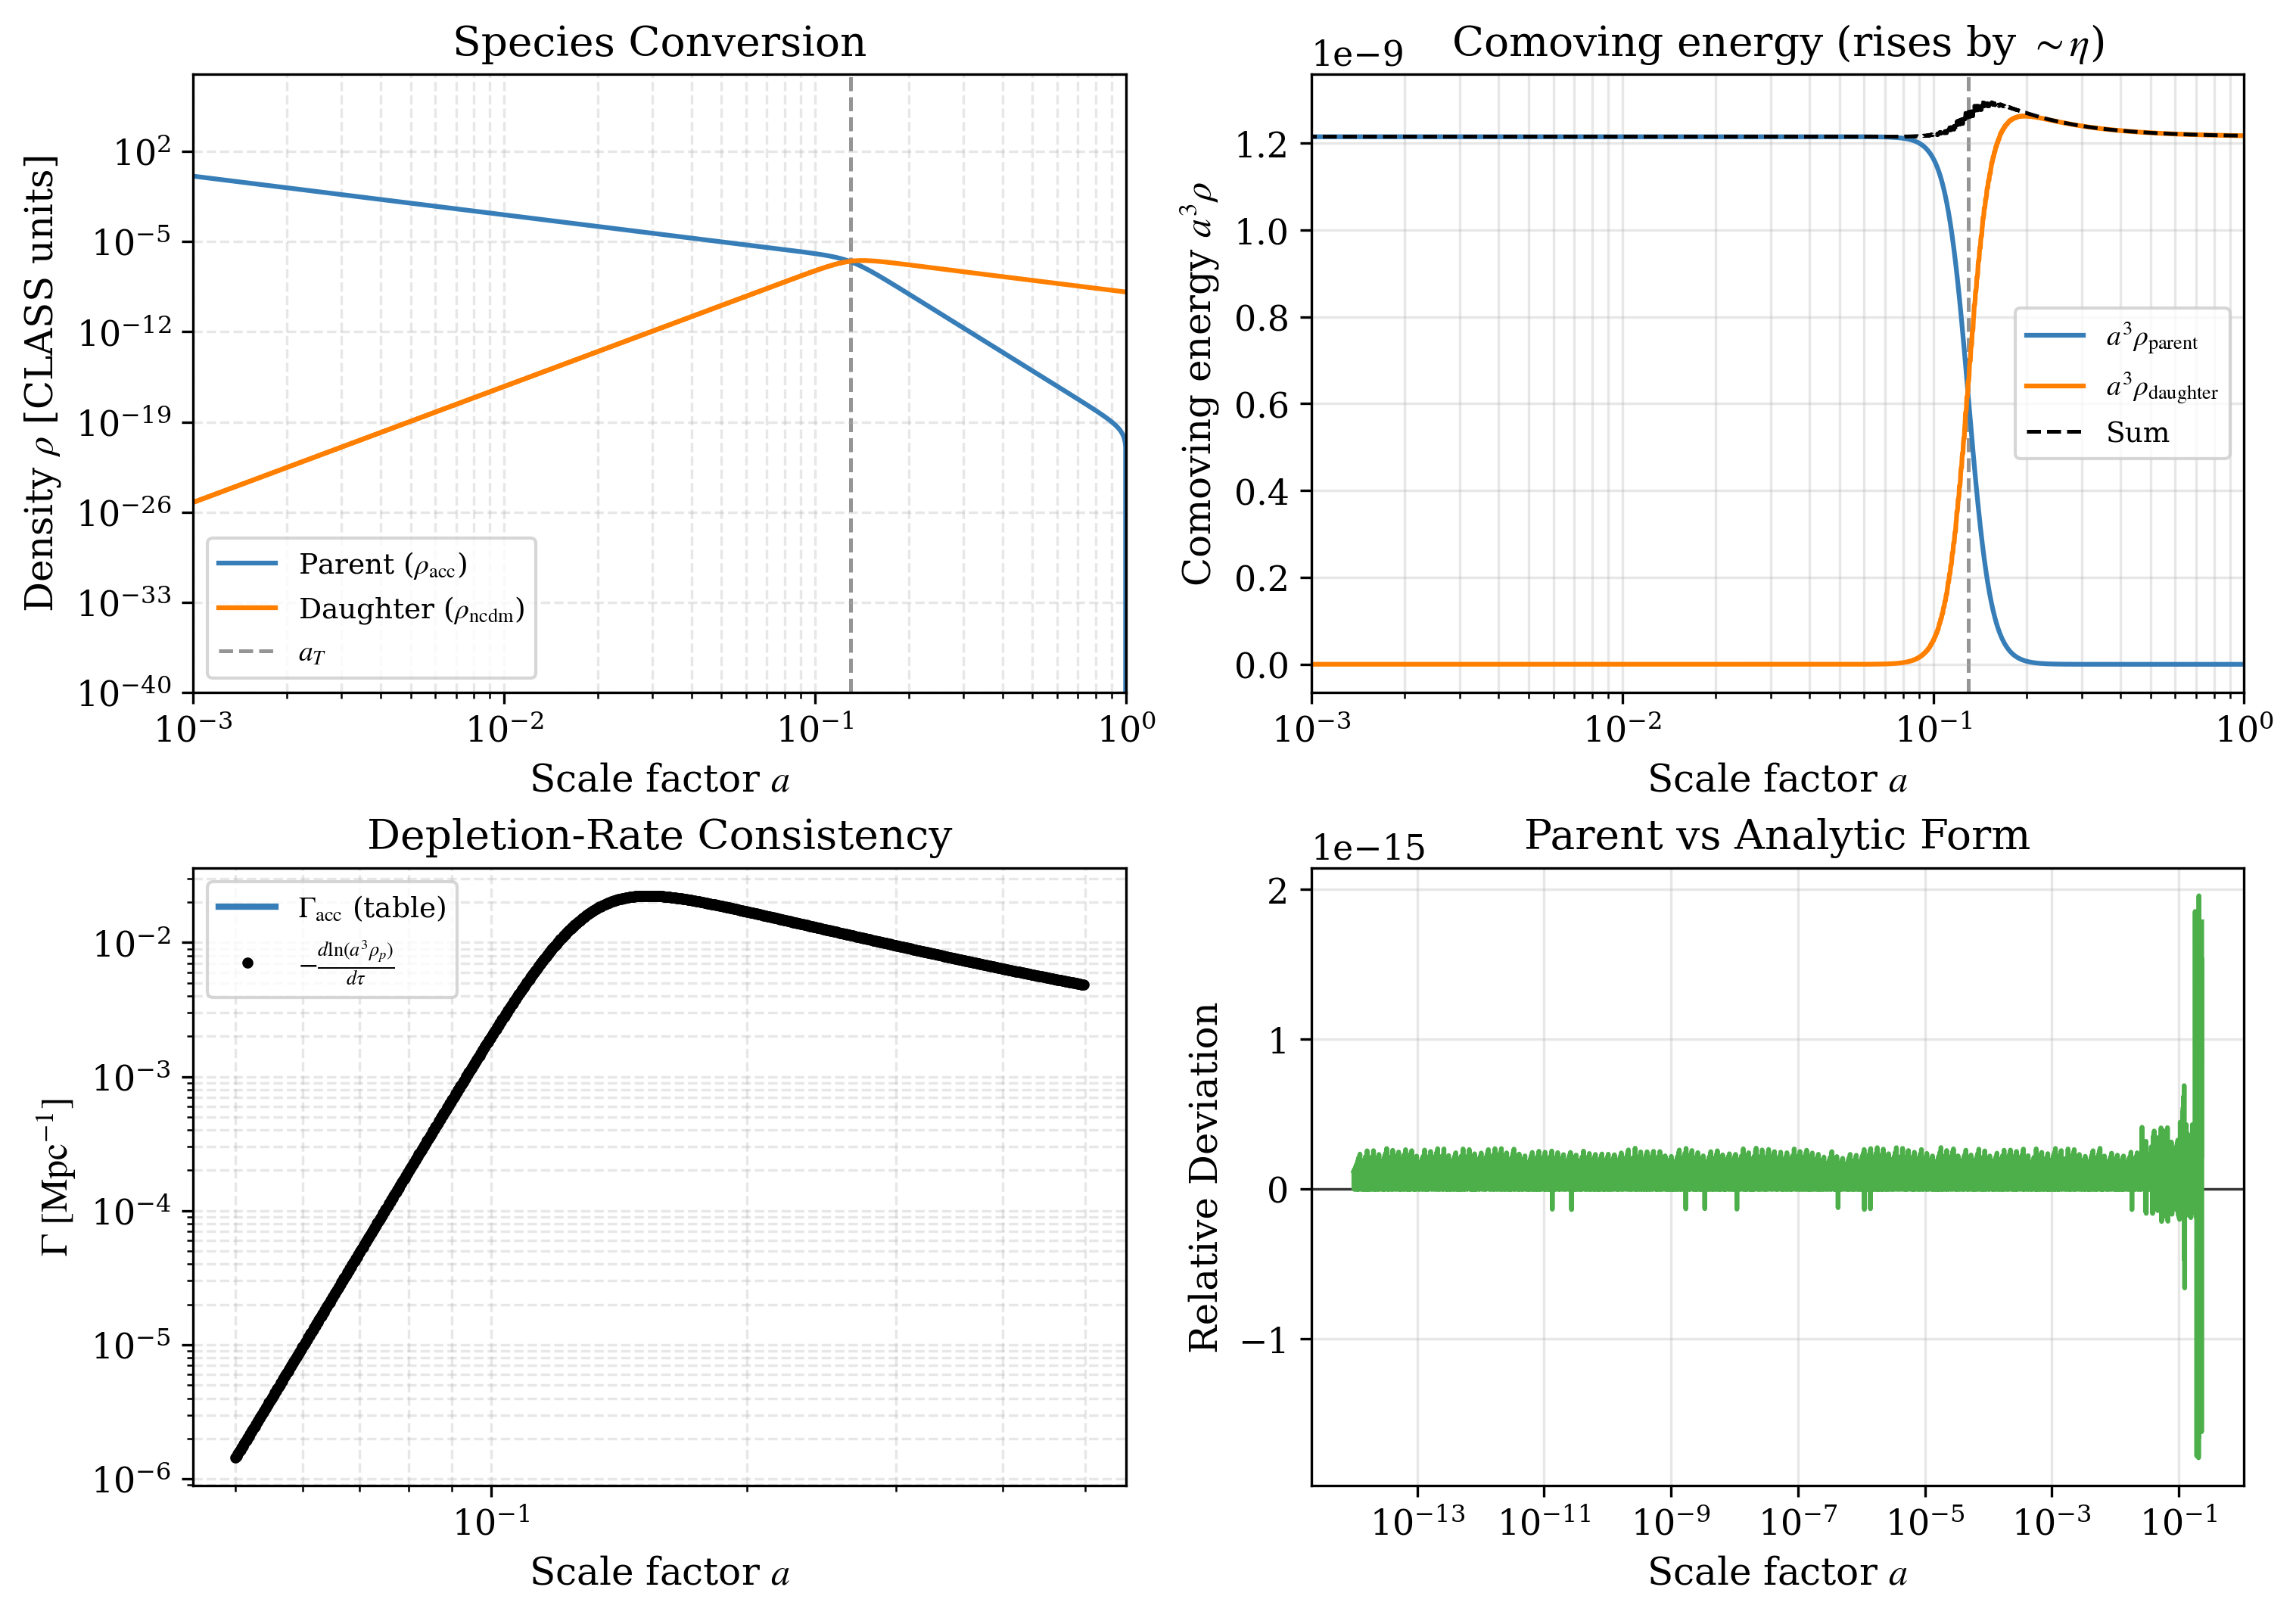

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Global Plotting Parameters (carrying over the standard we set previously)
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "figure.dpi": 300
})

# Use constrained_layout for optimal spatial arrangement of the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

# Qualitative palette for clear categorical distinction
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

rho_d = col(bg, dkey)

# ==============================================================================
# Top Left: Conversion (physical densities)
# ==============================================================================
ax = axes[0, 0]
ax.loglog(a, rho_p, color=qual_colors[0], label=r'Parent ($\rho_{\mathrm{acc}}$)')
ax.loglog(a, rho_d, color=qual_colors[1], label=r'Daughter ($\rho_{\mathrm{ncdm}}$)')

# Transition scale guide (pushed to background)
ax.axvline(A_T, color='dimgrey', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1, label=r'$a_T$')

ax.set_xlabel(r'Scale factor $a$')
ax.set_xlim(1e-3, 1.0)

ax.set_ylabel(r'Density $\rho$ [CLASS units]')
ax.set_ylim(1e-40, 1e8)

ax.set_title('Species Conversion')
ax.legend(loc='best')
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# ==============================================================================
# Top Right: Comoving energy
# ==============================================================================
ax = axes[0, 1]
ax.semilogx(a, a**3 * rho_p, color=qual_colors[0], label=r'$a^3 \rho_{\mathrm{parent}}$')
ax.semilogx(a, a**3 * rho_d, color=qual_colors[1], label=r'$a^3 \rho_{\mathrm{daughter}}$')
ax.semilogx(a, a**3 * (rho_p + rho_d), color='black', linestyle='--', linewidth=1.2, label='Sum', zorder=3)

# Transition scale guide
ax.axvline(A_T, color='dimgrey', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)

ax.set_xlabel(r'Scale factor $a$')
ax.set_xlim(1e-3, 1.0)
ax.set_ylabel(r'Comoving energy $a^3 \rho$')
ax.set_title(r'Comoving energy (rises by $\sim\eta$)')
ax.legend(loc='best')
ax.grid(True, which="both", alpha=0.3)

# ==============================================================================
# Bottom Left: Gamma_acc (numerical vs stored)
# ==============================================================================
ax = axes[1, 0]
# Plot the tabulated continuous data as a line
ax.loglog(a_s[band], gamma_s[band], color=qual_colors[0], linewidth=2, label=r'$\Gamma_{\mathrm{acc}}$ (table)')
# Plot the numerical derivative strictly as discrete points
ax.loglog(a_s[band], gamma_num[band], marker='.', linestyle='None', color='black', markersize=5, label=r'$-\frac{d \ln(a^3 \rho_p)}{d\tau}$')

ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Gamma \ [\mathrm{Mpc}^{-1}]$')
ax.set_title('Depletion-Rate Consistency')
ax.legend(loc='best')
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# ==============================================================================
# Bottom Right: Parent vs analytic residual
# ==============================================================================
ax = axes[1, 1]
ax.semilogx(a[m], (rho_p[m] - rho_p_analytic[m]) / rho_p_analytic[m], color=qual_colors[2], linewidth=1.5)

# Zero-deviation guide
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, zorder=1)

ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel('Relative Deviation')
ax.set_title('Parent vs Analytic Form')
ax.grid(True, which="both", alpha=0.3)

plt.show()

### Notes
- Background-only (`compute()` with no `output`) so it runs in seconds; `background_Nloga=4000` gives a fine enough grid for the C2 numerical derivative.
- C4 is the key normalization guard: `Omega_daughter/Omega_cdm` should equal `f_acc` to a fraction of a percent. The small positive excess is the leftover kinetic energy of the daughters; if you set `m_wdm != m_cdm`, the expected ratio becomes `f_acc * m_wdm/m_cdm`.
- pytest/nbmake: `pytest --nbmake notebooks_test/3_test_bg_conservation.ipynb`.